# Notebook 03 · OSM / Geofabrik: logística y accesibilidad

## Objetivo

En este notebook obtenemos y procesamos datos de OpenStreetMap mediante los extractos de Geofabrik. Con estos datos construimos variables territoriales relacionadas con la red viaria y los núcleos de población.

Trabajamos con España peninsular, Portugal continental y Andorra.

Analizamos:

- carreteras principales;
- longitud de la red viaria por región y tipo de vía;
- distribución de núcleos de población;
- una caracterización preliminar de la accesibilidad logística.

Primero buscamos los archivos OSM en Kaggle Input. Si los encontramos y superan nuestras comprobaciones, los reutilizamos. Si no están disponibles, los descargamos desde Geofabrik. Así evitamos descargas innecesarias y mantenemos un proceso reproducible.

Este notebook complementa los anteriores:

- Notebook 01: variables climáticas de ERA5-Land.
- Notebook 02: cobertura y uso del suelo de CORINE.
- Notebook 03: carreteras, núcleos de población y accesibilidad territorial preliminar.

Guardamos los resultados en capas geográficas, tablas, mapas, gráficos y un paquete final compacto. No incluimos los archivos RAW de gran tamaño dentro del paquete final.

La red viaria y la distribución de los núcleos de población se utilizan como una primera aproximación territorial a la accesibilidad logística. En este notebook no calculamos tiempos reales de desplazamiento ni distancias de proximidad, y estos resultados no determinan por sí solos la idoneidad final para instalar un centro de datos.

In [1]:
# instalacion de librerias geoespaciales
# GeoPandas permite leer y procesar las capas de Geofabrik.
%pip install -q geopandas pyogrio

Note: you may need to restart the kernel to use updated packages.


In [2]:
# preparacion del entorno y datos OSM
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

INPUT_DIR = Path("/kaggle/input")
BASE_DIR = Path("/kaggle/working/osm_geofabrik_logistica")
RAW_DIR = BASE_DIR / "raw"
PROCESSED_DIR = BASE_DIR / "processed"
TABLES_DIR = BASE_DIR / "tablas"
DASHBOARD_DIR = BASE_DIR / "dashboard"
FIGURES_DIR = DASHBOARD_DIR / "figuras"
MAPS_DIR = DASHBOARD_DIR / "mapas"
LOGS_DIR = BASE_DIR / "logs"

for carpeta in [
    RAW_DIR,
    PROCESSED_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MAPS_DIR,
    LOGS_DIR,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

# Buscamos los datos procesados.
archivos_gpkg = list(
    INPUT_DIR.rglob("osm_geofabrik_capas_iberia.gpkg")
)
ruta_gpkg_osm_input = (
    archivos_gpkg[0] if archivos_gpkg else None
)
datos_osm_en_input = ruta_gpkg_osm_input is not None
if datos_osm_en_input:
    tamano_mb = ruta_gpkg_osm_input.stat().st_size / 1024**2
    capas = set(
        gpd.list_layers(ruta_gpkg_osm_input)["name"]
    )
    capas_esperadas = {
        "roads_principales_iberia",
        "places_interes_iberia",
    }
    if tamano_mb < 100 or not capas_esperadas.issubset(capas):
        raise RuntimeError(
            "El GeoPackage de Input no es válido."
        )
    print("Utilizamos los datos OSM de Kaggle Input.")
    print("No realizaremos nuevas descargas.")
    print("Archivo:", ruta_gpkg_osm_input)
    print("Tamaño:", round(tamano_mb, 2), "MB")
    print("Capas:", sorted(capas))
else:
    print("No encontramos datos OSM en Input.")
    print("Descargaremos los archivos desde Geofabrik.")

Utilizamos los datos OSM de Kaggle Input.
No realizaremos nuevas descargas.
Archivo: /kaggle/input/datasets/aemjeloy/osm-geofabrik-capas-iberia/osm_geofabrik_capas_iberia.gpkg
Tamaño: 287.67 MB
Capas: ['places_interes_iberia', 'roads_principales_iberia']


In [3]:
# indice oficial de Geofabrick
from datetime import datetime, timezone
import json
import requests

url_indice_geofabrik = (
    "https://download.geofabrik.de/index-v1.json"
)

if datos_osm_en_input:
    origen_datos_osm = "Kaggle Input"

    print("Origen:", origen_datos_osm)
    print("Omitimos el índice y las descargas.")

else:
    origen_datos_osm = "Geofabrik"
    respuesta = requests.get(
        url_indice_geofabrik,
        timeout=120,
    )
    respuesta.raise_for_status()
    datos_indice_geofabrik = respuesta.json()

    if not datos_indice_geofabrik.get("features"):
        raise RuntimeError(
            "El índice de Geofabrik no contiene regiones."
        )
    fecha_consulta_geofabrik = datetime.now(
        timezone.utc
    ).strftime("%Y-%m-%dT%H:%M:%SZ")

    ruta_indice_geofabrik_json = (
        LOGS_DIR / "geofabrik_index_v1.json"
    )

    ruta_indice_geofabrik_json.write_text(
        json.dumps(
            datos_indice_geofabrik,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )

    print("Origen:", origen_datos_osm)
    print("Índice oficial consultado correctamente.")
    print("Fecha:", fecha_consulta_geofabrik)

Origen: Kaggle Input
Omitimos el índice y las descargas.


## (5) Criterio temporal

En el Notebook 01 trabajamos con datos climáticos horarios de ERA5-Land para el periodo 2024-2025 porque las condiciones meteorológicas cambian con el tiempo.

En el Notebook 02 utilizamos CORINE Land Cover 2018 como una capa territorial estática de cobertura y uso del suelo.

En este Notebook 03 tratamos OpenStreetMap como una representación de la infraestructura disponible en la fecha de referencia de los datos. Por tanto, no calculamos medias horarias ni construimos una serie temporal.

Utilizamos estas capas para estudiar:

- carreteras principales;
- longitud y distribución de la red viaria;
- distribución de núcleos de población;
- una caracterización preliminar de la accesibilidad logística.

Cuando reutilizamos el GeoPackage de Kaggle Input, conservamos la fecha registrada en sus atributos. Si descargamos nuevos datos desde Geofabrik, utilizamos la fecha de esa descarga.

Documentamos esta diferencia temporal y la tendremos en cuenta cuando integremos las distintas fuentes del proyecto.

In [4]:
# preparacion del indice Geofabrick
if datos_osm_en_input:
    print("Omitimos el índice: utilizamos Kaggle Input.")
else:
    regiones = []
    for elemento in datos_indice_geofabrik["features"]:
        datos = elemento.get("properties", {})
        urls = datos.get("urls") or {}
        regiones.append({
            "id": datos.get("id"),
            "name": datos.get("name"),
            "parent": datos.get("parent"),
            "url_shp": urls.get("shp"),
        })
    tabla_indice_geofabrik = pd.DataFrame(regiones)
    tabla_indice_geofabrik.to_csv(
        LOGS_DIR / "tabla_indice_geofabrik.csv",
        index=False,
    )
    print(
        "Índice preparado:",
        len(tabla_indice_geofabrik),
        "regiones.",
    )

Omitimos el índice: utilizamos Kaggle Input.


In [5]:
# regiones OSM del ambito de estudio
ids_regiones_osm = [
    "andalucia", "aragon", "asturias", "cantabria",
    "castilla-la-mancha", "castilla-y-leon", "cataluna",
    "extremadura", "galicia", "la-rioja", "madrid",
    "murcia", "navarra", "pais-vasco", "valencia",
    "portugal", "andorra",
]
if datos_osm_en_input:
    regiones = gpd.read_file(
        ruta_gpkg_osm_input,
        layer="roads_principales_iberia",
        columns=["region_id"],
        ignore_geometry=True,
    )
    tabla_regiones_osm = pd.DataFrame({
        "id": regiones["region_id"].dropna().unique()
    })
else:
    tabla_regiones_osm = tabla_indice_geofabrik[
        tabla_indice_geofabrik["id"].isin(
            ids_regiones_osm
        )
    ][["id", "name", "url_shp"]].copy()
    if tabla_regiones_osm["url_shp"].isna().any():
        raise RuntimeError(
            "Alguna región no tiene URL de descarga."
        )

# Comprobamos las 17 regiones esperadas.
if set(tabla_regiones_osm["id"]) != set(ids_regiones_osm):
    raise RuntimeError(
        "Las regiones no coinciden con el ámbito esperado."
    )
tabla_regiones_osm["origen"] = origen_datos_osm
tabla_regiones_osm = (
    tabla_regiones_osm
    .sort_values("id")
    .reset_index(drop=True)
)
tabla_regiones_osm.to_csv(
    LOGS_DIR / "regiones_osm_utilizadas.csv",
    index=False,
)
print("Regiones validadas:", len(tabla_regiones_osm))
display(tabla_regiones_osm)

Regiones validadas: 17


,id,origen
0,andalucia,Kaggle Input
1,andorra,Kaggle Input
2,aragon,Kaggle Input
3,asturias,Kaggle Input
4,cantabria,Kaggle Input
5,castilla-la-mancha,Kaggle Input
6,castilla-y-leon,Kaggle Input
7,cataluna,Kaggle Input
8,extremadura,Kaggle Input
9,galicia,Kaggle Input


In [6]:
# metadatos temporales OSM
from datetime import datetime, timezone

if datos_osm_en_input:
    metadatos = gpd.read_file(
        ruta_gpkg_osm_input,
        layer="roads_principales_iberia",
        columns=["fecha_descarga_osm", "fuente"],
        rows=1,
        ignore_geometry=True,
    )
    fecha_descarga_osm = metadatos[
        "fecha_descarga_osm"
    ].iloc[0]
    fuente_osm_geofabrik = metadatos[
        "fuente"
    ].iloc[0]

else:
    fecha_descarga_osm = datetime.now(
        timezone.utc
    ).strftime("%Y-%m-%d")
    fuente_osm_geofabrik = "OpenStreetMap / Geofabrik"
ruta_log_metadatos_osm = (
    LOGS_DIR / "metadatos_osm_geofabrik.txt"
)
ruta_log_metadatos_osm.write_text(
    f"Fuente: {fuente_osm_geofabrik}\n"
    f"Origen: {origen_datos_osm}\n"
    f"Fecha: {fecha_descarga_osm}\n",
    encoding="utf-8",
)
print("Fuente:", fuente_osm_geofabrik)
print("Origen:", origen_datos_osm)
print("Fecha:", fecha_descarga_osm)

Fuente: OpenStreetMap / Geofabrik
Origen: Kaggle Input
Fecha: 2026-07-04


In [7]:
# plan de descarga Geofabrick
if datos_osm_en_input:
    print("Omitimos las descargas: utilizamos Kaggle Input.")
else:
    tabla_descargas_osm = tabla_regiones_osm[
        ["id", "name", "url_shp"]
    ].copy()
    tabla_descargas_osm["tipo_ambito"] = (
        "España peninsular"
    )
    tabla_descargas_osm.loc[
        tabla_descargas_osm["id"] == "portugal",
        "tipo_ambito",
    ] = "Portugal"
    tabla_descargas_osm.loc[
        tabla_descargas_osm["id"] == "andorra",
        "tipo_ambito",
    ] = "Andorra"
    tabla_descargas_osm["ruta_zip"] = [
        str(RAW_DIR / region / url.rsplit("/", 1)[-1])
        for region, url in zip(
            tabla_descargas_osm["id"],
            tabla_descargas_osm["url_shp"],
        )
    ]
    tabla_descargas_osm["fecha"] = fecha_descarga_osm
    tabla_descargas_osm.to_csv(
        LOGS_DIR / "plan_descargas_geofabrik.csv",
        index=False,
    )
    print("Descargas planificadas:", len(tabla_descargas_osm))
    display(tabla_descargas_osm)

Omitimos las descargas: utilizamos Kaggle Input.


In [8]:
# descarga de datos OSM
import shutil
import requests
import zipfile

if datos_osm_en_input:
    print("Omitimos la descarga: utilizamos Kaggle Input.")
else:
    espacio_gb = (
        shutil.disk_usage("/kaggle/working").free
        / 1024**3
    )
    if espacio_gb < 6:
        raise RuntimeError("No hay espacio suficiente.")
    estados = []
    tamanos = []

    for _, fila in tabla_descargas_osm.iterrows():
        ruta_zip = Path(fila["ruta_zip"])
        ruta_zip.parent.mkdir(
            parents=True,
            exist_ok=True,
        )
        if zipfile.is_zipfile(ruta_zip):
            estado = "reutilizado"
        else:
            with requests.get(
                fila["url_shp"],
                stream=True,
                timeout=600,
            ) as respuesta:
                respuesta.raise_for_status()

                with ruta_zip.open("wb") as archivo:
                    for bloque in respuesta.iter_content(
                        chunk_size=1024**2
                    ):
                        if bloque:
                            archivo.write(bloque)

            if not zipfile.is_zipfile(ruta_zip):
                raise RuntimeError(
                    "La descarga no es un ZIP válido."
                )
            estado = "descargado"
        estados.append(estado)
        tamanos.append(
            round(ruta_zip.stat().st_size / 1024**2, 2)
        )
        print(fila["id"], "|", estado)

    tabla_descargas_osm_raw = tabla_descargas_osm.copy()
    tabla_descargas_osm_raw["estado"] = estados
    tabla_descargas_osm_raw["tamano_mb"] = tamanos
    tabla_descargas_osm_raw.to_csv(
        LOGS_DIR / "descargas_osm_geofabrik.csv",
        index=False,
    )
    print("Regiones preparadas:", len(tabla_descargas_osm_raw))

Omitimos la descarga: utilizamos Kaggle Input.


In [9]:
# configuracion del procesaminento OSM
REGIONES_PROCESADAS_DIR = PROCESSED_DIR / "regiones"
ROADS_PROCESSED_DIR = REGIONES_PROCESADAS_DIR / "roads"
PLACES_PROCESSED_DIR = REGIONES_PROCESADAS_DIR / "places"
TEMP_DIR = BASE_DIR / "temp"

for carpeta in [
    ROADS_PROCESSED_DIR,
    PLACES_PROCESSED_DIR,
    TEMP_DIR,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

# Caja aproximada de la Iberia continental.
bbox_iberia = (-10.5, 35.5, 4.5, 44.5)

# Clases OSM que utilizaremos.
tipos_vias_principales = [
    "motorway", "trunk", "primary", "secondary",
    "motorway_link", "trunk_link",
    "primary_link", "secondary_link",
]
tipos_lugares_interes = [
    "city", "town", "village", "hamlet",
]
print("Configuración del procesamiento preparada.")
print("Origen:", origen_datos_osm)

Configuración del procesamiento preparada.
Origen: Kaggle Input


In [10]:
# carga o procesamiento de las capas OSM
import shutil
import zipfile

if datos_osm_en_input:
    roads_principales_iberia = gpd.read_file(
        ruta_gpkg_osm_input,
        layer="roads_principales_iberia",
    )

    places_interes_iberia = gpd.read_file(
        ruta_gpkg_osm_input,
        layer="places_interes_iberia",
    )
    ruta_gpkg_capas_osm_iberia = ruta_gpkg_osm_input
    print("Utilizamos las capas de Kaggle Input.")

else:
    lista_roads = []
    lista_places = []

    for _, fila in tabla_descargas_osm_raw.iterrows():
        carpeta = TEMP_DIR / fila["id"]
        carpeta.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(fila["ruta_zip"]) as archivo:
            archivo.extractall(carpeta)
        ruta_roads = next(
            carpeta.rglob("gis_osm_roads_free_1.shp")
        )
        ruta_places = next(
            carpeta.rglob("gis_osm_places_free_1.shp")
        )
        roads = gpd.read_file(
            ruta_roads,
            bbox=bbox_iberia,
        )
        places = gpd.read_file(
            ruta_places,
            bbox=bbox_iberia,
        )
        roads = roads[
            roads["fclass"].isin(tipos_vias_principales)
        ].copy()
        places = places[
            places["fclass"].isin(tipos_lugares_interes)
        ].copy()
        roads["longitud_km"] = (
            roads.to_crs("EPSG:3035").length / 1000
        )

        metadatos = {
            "region_id": fila["id"],
            "region_nombre": fila["name"],
            "tipo_ambito": fila["tipo_ambito"],
            "fuente": "OpenStreetMap / Geofabrik",
            "url_fuente": fila["url_shp"],
            "fecha_descarga_osm": fila["fecha"],
        }
        roads = roads.assign(**metadatos)
        places = places.assign(**metadatos)
        lista_roads.append(roads)
        lista_places.append(places)

    roads_principales_iberia = gpd.GeoDataFrame(
        pd.concat(lista_roads, ignore_index=True),
        crs="EPSG:4326",
    )
    places_interes_iberia = gpd.GeoDataFrame(
        pd.concat(lista_places, ignore_index=True),
        crs="EPSG:4326",
    )
    ruta_gpkg_capas_osm_iberia = (
        PROCESSED_DIR / "osm_geofabrik_capas_iberia.gpkg"
    )
    roads_principales_iberia.to_file(
        ruta_gpkg_capas_osm_iberia,
        layer="roads_principales_iberia",
        driver="GPKG",
    )
    places_interes_iberia.to_file(
        ruta_gpkg_capas_osm_iberia,
        layer="places_interes_iberia",
        driver="GPKG",
        mode="a",
    )
    shutil.rmtree(TEMP_DIR)
    
print("Carreteras:", len(roads_principales_iberia))
print("Poblaciones:", len(places_interes_iberia))
print("Archivo:", ruta_gpkg_capas_osm_iberia)

Utilizamos las capas de Kaggle Input.
Carreteras: 549072
Poblaciones: 85331
Archivo: /kaggle/input/datasets/aemjeloy/osm-geofabrik-capas-iberia/osm_geofabrik_capas_iberia.gpkg


In [11]:
# validacion y resumen de las capas OSM

# Validamos las capas.
for nombre, capa in {
    "roads": roads_principales_iberia,
    "places": places_interes_iberia,
}.items():

    if capa.crs is None:
        raise RuntimeError(f"{nombre} no tiene CRS.")

    if capa.geometry.isna().any() or capa.geometry.is_empty.any():
        raise RuntimeError(
            f"{nombre} contiene geometrías vacías."
        )

    if set(capa["region_id"].dropna()) != set(ids_regiones_osm):
        raise RuntimeError(
            f"Las regiones de {nombre} no son correctas."
        )

# Resumen general.
longitud_total_roads_km = (
    roads_principales_iberia["longitud_km"].sum()
)

tabla_resumen_osm_iberia = pd.DataFrame({
    "capa": [
        "roads_principales_iberia",
        "places_interes_iberia",
    ],
    "elementos": [
        len(roads_principales_iberia),
        len(places_interes_iberia),
    ],
    "longitud_km": [
        round(longitud_total_roads_km, 2),
        None,
    ],
})

# Resumen por tipo de vía.
tabla_roads_por_tipo = (
    roads_principales_iberia
    .groupby("fclass")
    .agg(
        tramos=("fclass", "size"),
        longitud_km=("longitud_km", "sum"),
    )
    .reset_index()
)

tabla_roads_por_tipo["longitud_km"] = (
    tabla_roads_por_tipo["longitud_km"].round(2)
)

# Resumen por tipo de población.
tabla_places_por_tipo = (
    places_interes_iberia
    .groupby("fclass")
    .size()
    .reset_index(name="lugares")
)

# Resumen por región.
tabla_resumen_regional_osm_iberia = (
    roads_principales_iberia
    .groupby("region_id")
    .agg(
        tramos=("fclass", "size"),
        longitud_km=("longitud_km", "sum"),
    )
    .join(
        places_interes_iberia
        .groupby("region_id")
        .size()
        .rename("lugares")
    )
    .reset_index()
)

tabla_resumen_regional_osm_iberia["longitud_km"] = (
    tabla_resumen_regional_osm_iberia[
        "longitud_km"
    ].round(2)
)

# Rutas de salida.
ruta_tabla_resumen_osm_iberia = (
    TABLES_DIR / "tabla_resumen_osm_iberia.csv"
)
ruta_tabla_roads_por_tipo = (
    TABLES_DIR / "tabla_roads_por_tipo.csv"
)
ruta_tabla_places_por_tipo = (
    TABLES_DIR / "tabla_places_por_tipo.csv"
)
ruta_tabla_resumen_regional_osm_iberia = (
    TABLES_DIR / "tabla_resumen_regional_osm.csv"
)

# Guardamos las tablas.
tabla_resumen_osm_iberia.to_csv(
    ruta_tabla_resumen_osm_iberia,
    index=False,
)
tabla_roads_por_tipo.to_csv(
    ruta_tabla_roads_por_tipo,
    index=False,
)
tabla_places_por_tipo.to_csv(
    ruta_tabla_places_por_tipo,
    index=False,
)
tabla_resumen_regional_osm_iberia.to_csv(
    ruta_tabla_resumen_regional_osm_iberia,
    index=False,
)

print("Capas validadas correctamente.")
print("Regiones:", len(ids_regiones_osm))
print("Carreteras:", len(roads_principales_iberia))
print("Poblaciones:", len(places_interes_iberia))
print(
    "Longitud:",
    round(longitud_total_roads_km, 2),
    "km",
)

display(tabla_resumen_osm_iberia)
display(tabla_roads_por_tipo)
display(tabla_places_por_tipo)
display(tabla_resumen_regional_osm_iberia)

Capas validadas correctamente.
Regiones: 17
Carreteras: 549072
Poblaciones: 85331
Longitud: 163706.35 km


,capa,elementos,longitud_km
0,roads_principales_iberia,549072,163706.35
1,places_interes_iberia,85331,NaN


,fclass,tramos,longitud_km
0,motorway,55958,38277.01
1,motorway_link,48454,9832.29
2,primary,139892,37119.56
3,primary_link,22581,1529.62
4,secondary,170817,52525.78
5,secondary_link,16966,881.76
6,trunk,69040,20648.80
7,trunk_link,25364,2891.53


,fclass,lugares
0,city,231
1,hamlet,72768
2,town,1400
3,village,10932


,region_id,tramos,longitud_km,lugares
0,andalucia,68261,18511.49,3196
1,andorra,1530,282.54,68
2,aragon,22481,9231.36,1636
3,asturias,10127,3582.08,7248
4,cantabria,9768,2228.69,1278
5,castilla-la-mancha,35079,16172.29,1693
6,castilla-y-leon,52332,19600.41,6076
7,cataluna,60125,10906.79,3079
8,extremadura,12828,6423.55,630
9,galicia,32636,9604.88,37148


In [12]:
# resumenes OSM por region y tipo
grupos = [
    "region_nombre",
    "region_id",
    "tipo_ambito",
    "fclass",
]
resumen_carreteras_region_tipo = (
    roads_principales_iberia
    .groupby(grupos)
    .agg(
        tramos=("fclass", "size"),
        longitud_km=("longitud_km", "sum"),
    )
    .reset_index()
)
resumen_carreteras_region_tipo["longitud_km"] = (
    resumen_carreteras_region_tipo["longitud_km"].round(2)
)
resumen_lugares_region_tipo = (
    places_interes_iberia
    .groupby(grupos)
    .size()
    .reset_index(name="lugares")
)
ruta_resumen_carreteras_region_tipo = (
    TABLES_DIR / "resumen_carreteras_por_region_tipo.csv"
)
ruta_resumen_lugares_region_tipo = (
    TABLES_DIR / "resumen_lugares_por_region_tipo.csv"
)
resumen_carreteras_region_tipo.to_csv(
    ruta_resumen_carreteras_region_tipo,
    index=False,
)
resumen_lugares_region_tipo.to_csv(
    ruta_resumen_lugares_region_tipo,
    index=False,
)

print("Resumen de carreteras:", len(resumen_carreteras_region_tipo))
print("Resumen de poblaciones:", len(resumen_lugares_region_tipo))

display(resumen_carreteras_region_tipo.head(10))
display(resumen_lugares_region_tipo.head(10))

Resumen de carreteras: 134
Resumen de poblaciones: 67


,region_nombre,region_id,tipo_ambito,fclass,tramos,longitud_km
0,Andalucía,andalucia,España peninsular,motorway,7675,5389.92
1,Andalucía,andalucia,España peninsular,motorway_link,6763,1332.20
2,Andalucía,andalucia,España peninsular,primary,13292,2544.79
3,Andalucía,andalucia,España peninsular,primary_link,2718,175.71
4,Andalucía,andalucia,España peninsular,secondary,24524,6570.55
5,Andalucía,andalucia,España peninsular,secondary_link,4310,229.10
6,Andalucía,andalucia,España peninsular,trunk,6314,2013.86
7,Andalucía,andalucia,España peninsular,trunk_link,2665,255.37
8,Andorra,andorra,Andorra,primary,705,94.58
9,Andorra,andorra,Andorra,primary_link,31,1.46


,region_nombre,region_id,tipo_ambito,fclass,lugares
0,Andalucía,andalucia,España peninsular,city,15
1,Andalucía,andalucia,España peninsular,hamlet,2224
2,Andalucía,andalucia,España peninsular,town,156
3,Andalucía,andalucia,España peninsular,village,801
4,Andorra,andorra,Andorra,hamlet,27
5,Andorra,andorra,Andorra,town,7
6,Andorra,andorra,Andorra,village,34
7,Aragón,aragon,España peninsular,city,3
8,Aragón,aragon,España peninsular,hamlet,885
9,Aragón,aragon,España peninsular,town,37


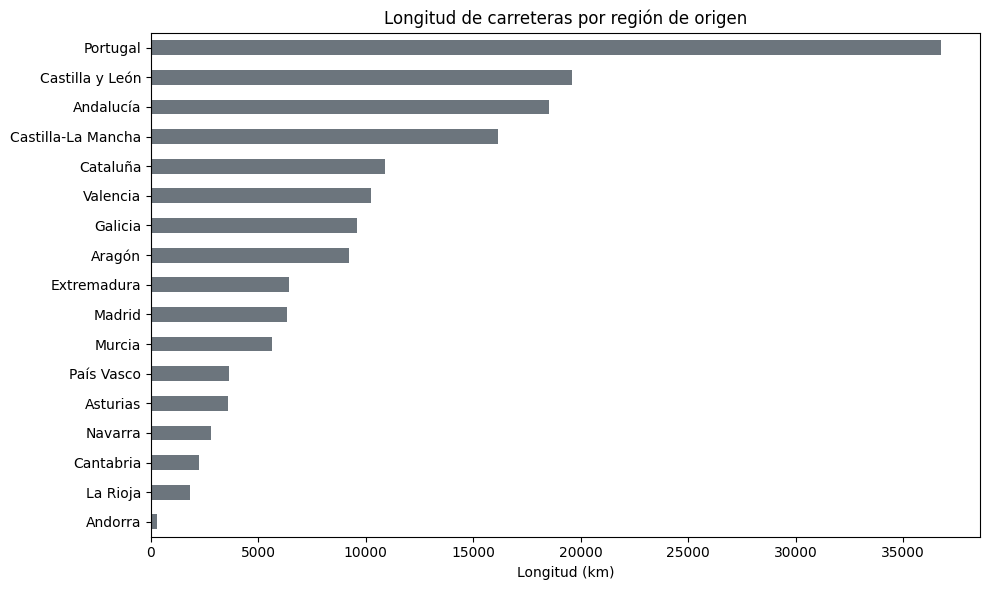

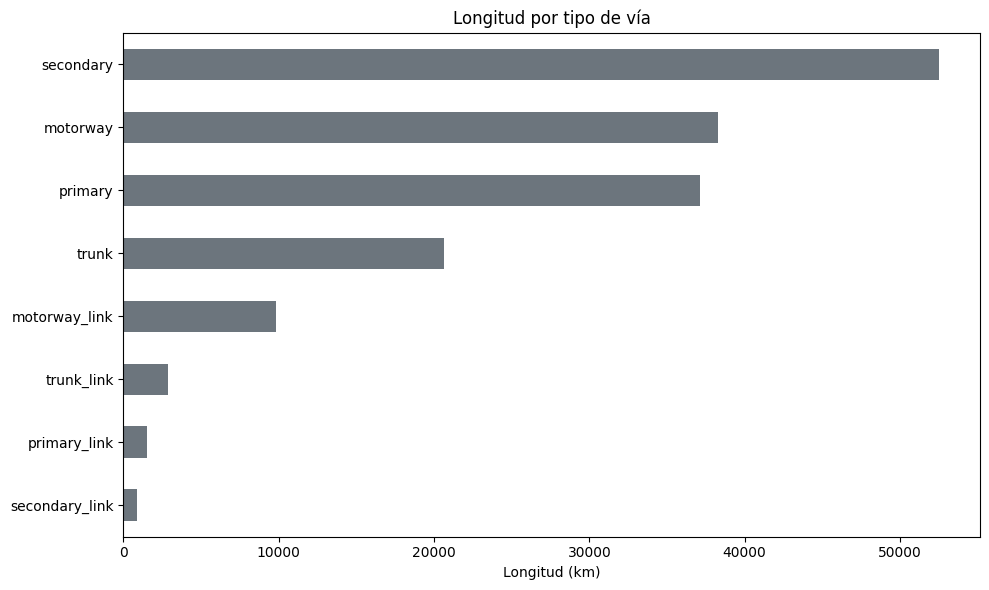

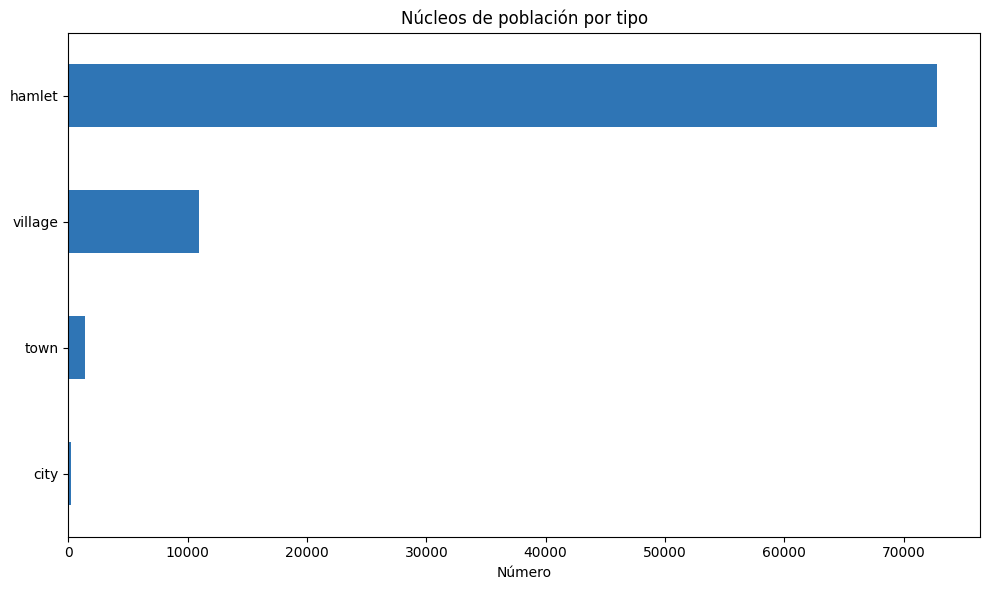

Gráficos generados: 3


,figura,ruta
0,Longitud por región,/kaggle/working/osm_geofabrik_logistica/dashbo...
1,Longitud por tipo de vía,/kaggle/working/osm_geofabrik_logistica/dashbo...
2,Poblaciones por tipo,/kaggle/working/osm_geofabrik_logistica/dashbo...


In [13]:
# graficos resumen OSM
tabla_longitud_region = (
    roads_principales_iberia
    .groupby("region_nombre", as_index=False)
    ["longitud_km"].sum()
)

def crear_grafico(
    tabla,
    categoria,
    valor,
    titulo,
    nombre,
    color,
):
    datos = tabla.sort_values(valor)
    datos.plot.barh(
        x=categoria,
        y=valor,
        figsize=(10, 6),
        legend=False,
        color=color,
    )
    plt.title(titulo)
    plt.xlabel(
        "Longitud (km)"
        if "longitud" in valor
        else "Número"
    )
    plt.ylabel("")
    plt.tight_layout()

    ruta = FIGURES_DIR / nombre
    plt.savefig(ruta, dpi=200)
    plt.show()
    plt.close()
    return ruta

# Gris para carreteras.
ruta_grafico_longitud_region = crear_grafico(
    tabla_longitud_region,
    "region_nombre",
    "longitud_km",
    "Longitud de carreteras por región de origen",
    "longitud_carreteras_por_region.png",
    "#6c757d",
)
ruta_grafico_longitud_tipo = crear_grafico(
    tabla_roads_por_tipo,
    "fclass",
    "longitud_km",
    "Longitud por tipo de vía",
    "longitud_carreteras_por_tipo.png",
    "#6c757d",
)

# Azul para población.
ruta_grafico_places_tipo = crear_grafico(
    tabla_places_por_tipo,
    "fclass",
    "lugares",
    "Núcleos de población por tipo",
    "poblaciones_por_tipo.png",
    "#2f75b5",
)
tabla_figuras_osm = pd.DataFrame({
    "figura": [
        "Longitud por región",
        "Longitud por tipo de vía",
        "Poblaciones por tipo",
    ],
    "ruta": [
        ruta_grafico_longitud_region,
        ruta_grafico_longitud_tipo,
        ruta_grafico_places_tipo,
    ],
})
ruta_tabla_figuras_osm = (
    LOGS_DIR / "tabla_figuras_osm.csv"
)
tabla_figuras_osm.to_csv(
    ruta_tabla_figuras_osm,
    index=False,
)

print("Gráficos generados:", len(tabla_figuras_osm))
display(tabla_figuras_osm)

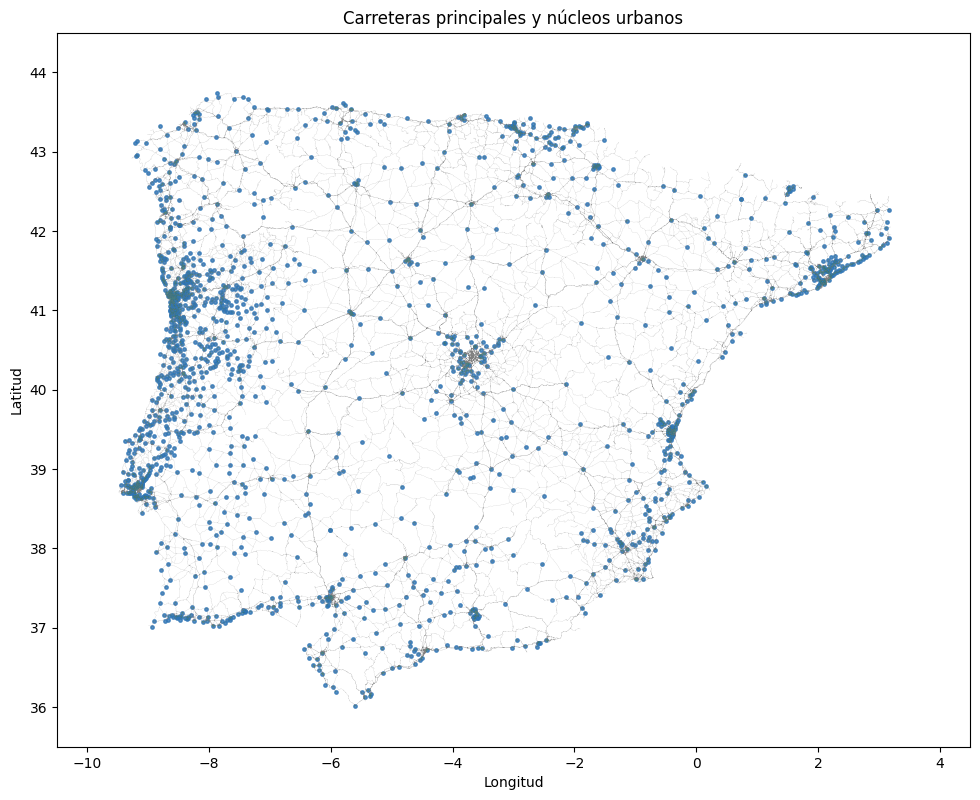

Mapa guardado: /kaggle/working/osm_geofabrik_logistica/dashboard/mapas/mapa_carreteras_nucleos.png
Núcleos representados: 1631
Tipos representados: ['city', 'town']


In [14]:
#  mapa de carreteras y nucleos urbanos

# Representamos únicamente ciudades y localidades principales.
# Village y hamlet permanecen disponibles en los datos.
places_mapa = places_interes_iberia[
    places_interes_iberia["fclass"].isin(
        ["city", "town"]
    )
].copy()

x_min, y_min, x_max, y_max = bbox_iberia
fig, ax = plt.subplots(figsize=(10, 8))

# Carreteras en gris.
roads_principales_iberia.plot(
    ax=ax,
    color="#808080",
    linewidth=0.12,
    alpha=0.6,
)

# Núcleos urbanos en azul.
places_mapa.plot(
    ax=ax,
    color="#2f75b5",
    markersize=6,
    alpha=0.8,
)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title(
    "Carreteras principales y núcleos urbanos"
)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ruta_mapa_combinado_osm = (
    MAPS_DIR / "mapa_carreteras_nucleos.png"
)
plt.tight_layout()
plt.savefig(
    ruta_mapa_combinado_osm,
    dpi=200,
)
plt.show()
plt.close()
tabla_mapas_osm = pd.DataFrame({
    "mapa": [
        "Carreteras principales y núcleos urbanos"
    ],
    "ruta": [
        ruta_mapa_combinado_osm
    ],
})
ruta_tabla_mapas_osm = (
    LOGS_DIR / "tabla_mapas_osm.csv"
)
tabla_mapas_osm.to_csv(
    ruta_tabla_mapas_osm,
    index=False,
)
print("Mapa guardado:", ruta_mapa_combinado_osm)
print("Núcleos representados:", len(places_mapa))
print("Tipos representados:", sorted(places_mapa["fclass"].unique()))

In [15]:
# dashboard HTML
numero_roads = len(roads_principales_iberia)
numero_places = len(places_interes_iberia)
longitud_total_km = roads_principales_iberia[
    "longitud_km"
].sum()

tabla_regiones = (
    roads_principales_iberia[
        ["region_id", "region_nombre"]
    ]
    .drop_duplicates()
    .merge(
        tabla_resumen_regional_osm_iberia,
        on="region_id",
    )
)

ruta_dashboard_osm = (
    DASHBOARD_DIR / "dashboard_osm_geofabrik_iberia.html"
)

html = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<title>Dashboard OSM-Geofabrik</title>
<style>
body {{font-family: Arial; margin: 40px; color: #222;}}
h1, h2 {{color: #30475e;}}
img {{max-width: 900px; width: 100%;}}
table {{border-collapse: collapse; width: 100%;}}
th, td {{padding: 7px; border: 1px solid #ddd;}}
th {{background: #30475e; color: white;}}
.nota {{background: #fff4d6; padding: 12px;}}
</style>
</head>
<body>

<h1>Notebook 03 · OSM / Geofabrik</h1>

<p>
Analizamos carreteras principales y núcleos de población
de España peninsular, Portugal y Andorra.
</p>

<ul>
<li>Origen: {origen_datos_osm}</li>
<li>Fecha: {fecha_descarga_osm}</li>
<li>Carreteras: {numero_roads:,}</li>
<li>Longitud total: {longitud_total_km:,.2f} km</li>
<li>Núcleos de población: {numero_places:,}</li>
</ul>

<p class="nota">
La red viaria y los núcleos de población proporcionan una
caracterización preliminar de la accesibilidad logística.
Portugal aparece como un único extracto de origen.
</p>

<h2>Mapa de carreteras y núcleos urbanos</h2>
<img src="mapas/mapa_carreteras_nucleos.png">

<h2>Longitud de carreteras por región</h2>
<img src="figuras/longitud_carreteras_por_region.png">

<h2>Longitud por tipo de vía</h2>
<img src="figuras/longitud_carreteras_por_tipo.png">

<h2>Núcleos de población por tipo</h2>
<img src="figuras/poblaciones_por_tipo.png">

<h2>Tipos de vía</h2>
{tabla_roads_por_tipo.to_html(index=False)}

<h2>Tipos de población</h2>
{tabla_places_por_tipo.to_html(index=False)}

<h2>Resumen regional</h2>
{tabla_regiones.to_html(index=False)}

</body>
</html>
"""

ruta_dashboard_osm.write_text(
    html,
    encoding="utf-8",
)

print("Dashboard creado:", ruta_dashboard_osm)

Dashboard creado: /kaggle/working/osm_geofabrik_logistica/dashboard/dashboard_osm_geofabrik_iberia.html


In [16]:
# ZIP final de resultados
import zipfile

ruta_zip_osm_final = Path(
    "/kaggle/working/osm_geofabrik_resultados.zip"
)
archivos_finales = {
    "osm_geofabrik_capas_iberia.gpkg":
        ruta_gpkg_capas_osm_iberia,
    "tablas/resumen_osm_iberia.csv":
        ruta_tabla_resumen_osm_iberia,
    "tablas/roads_por_tipo.csv":
        ruta_tabla_roads_por_tipo,
    "tablas/places_por_tipo.csv":
        ruta_tabla_places_por_tipo,
    "tablas/resumen_regional.csv":
        ruta_tabla_resumen_regional_osm_iberia,
    "tablas/carreteras_region_tipo.csv":
        ruta_resumen_carreteras_region_tipo,
    "tablas/lugares_region_tipo.csv":
        ruta_resumen_lugares_region_tipo,
    "dashboard/dashboard_osm_geofabrik_iberia.html":
        ruta_dashboard_osm,
    "dashboard/mapas/mapa_carreteras_nucleos.png":
        ruta_mapa_combinado_osm,
    "dashboard/figuras/longitud_carreteras_por_region.png":
        ruta_grafico_longitud_region,
    "dashboard/figuras/longitud_carreteras_por_tipo.png":
        ruta_grafico_longitud_tipo,
    "dashboard/figuras/poblaciones_por_tipo.png":
        ruta_grafico_places_tipo,
    "metadatos/metadatos_osm.txt":
        ruta_log_metadatos_osm,
    "metadatos/regiones_osm.csv":
        LOGS_DIR / "regiones_osm_utilizadas.csv",
}

with zipfile.ZipFile(
    ruta_zip_osm_final,
    "w",
    zipfile.ZIP_DEFLATED,
) as archivo_zip:

    for nombre, ruta in archivos_finales.items():
        if not Path(ruta).exists():
            raise FileNotFoundError(
                f"No se encuentra: {ruta}"
            )
        archivo_zip.write(
            ruta,
            arcname=nombre,
        )
if not zipfile.is_zipfile(ruta_zip_osm_final):
    raise RuntimeError(
        "El archivo creado no es un ZIP válido."
    )
tamano_mb = (
    ruta_zip_osm_final.stat().st_size
    / 1024**2
)

print("ZIP final:", ruta_zip_osm_final)
print("Archivos incluidos:", len(archivos_finales))
print("Tamaño:", round(tamano_mb, 2), "MB")

ZIP final: /kaggle/working/osm_geofabrik_resultados.zip
Archivos incluidos: 14
Tamaño: 101.11 MB
